In [1]:
# ============================================
# IRIS FLOWER CLASSIFICATION
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
# Load the built-in Iris dataset from scikit-learn
iris = load_iris()

# Display the available information
print("Dataset loaded successfully!")
print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)


Dataset loaded successfully!

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [3]:
# Create DataFrame from the feature data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species names for easier interpretation
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display first five rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [4]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)
# Check data types of each column
print("Data types:")
print(df.dtypes)


Dataset shape: (150, 6)
Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object


In [5]:
# Check the number of missing values in each column
print("Missing values:")
print(df.isnull().sum())
# Display descriptive statistics
df.describe()


Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Count the number of samples in each species
print("Species distribution:")
print(df["species"].value_counts())
# Display general information about the dataset
df.info()


Species distribution:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB


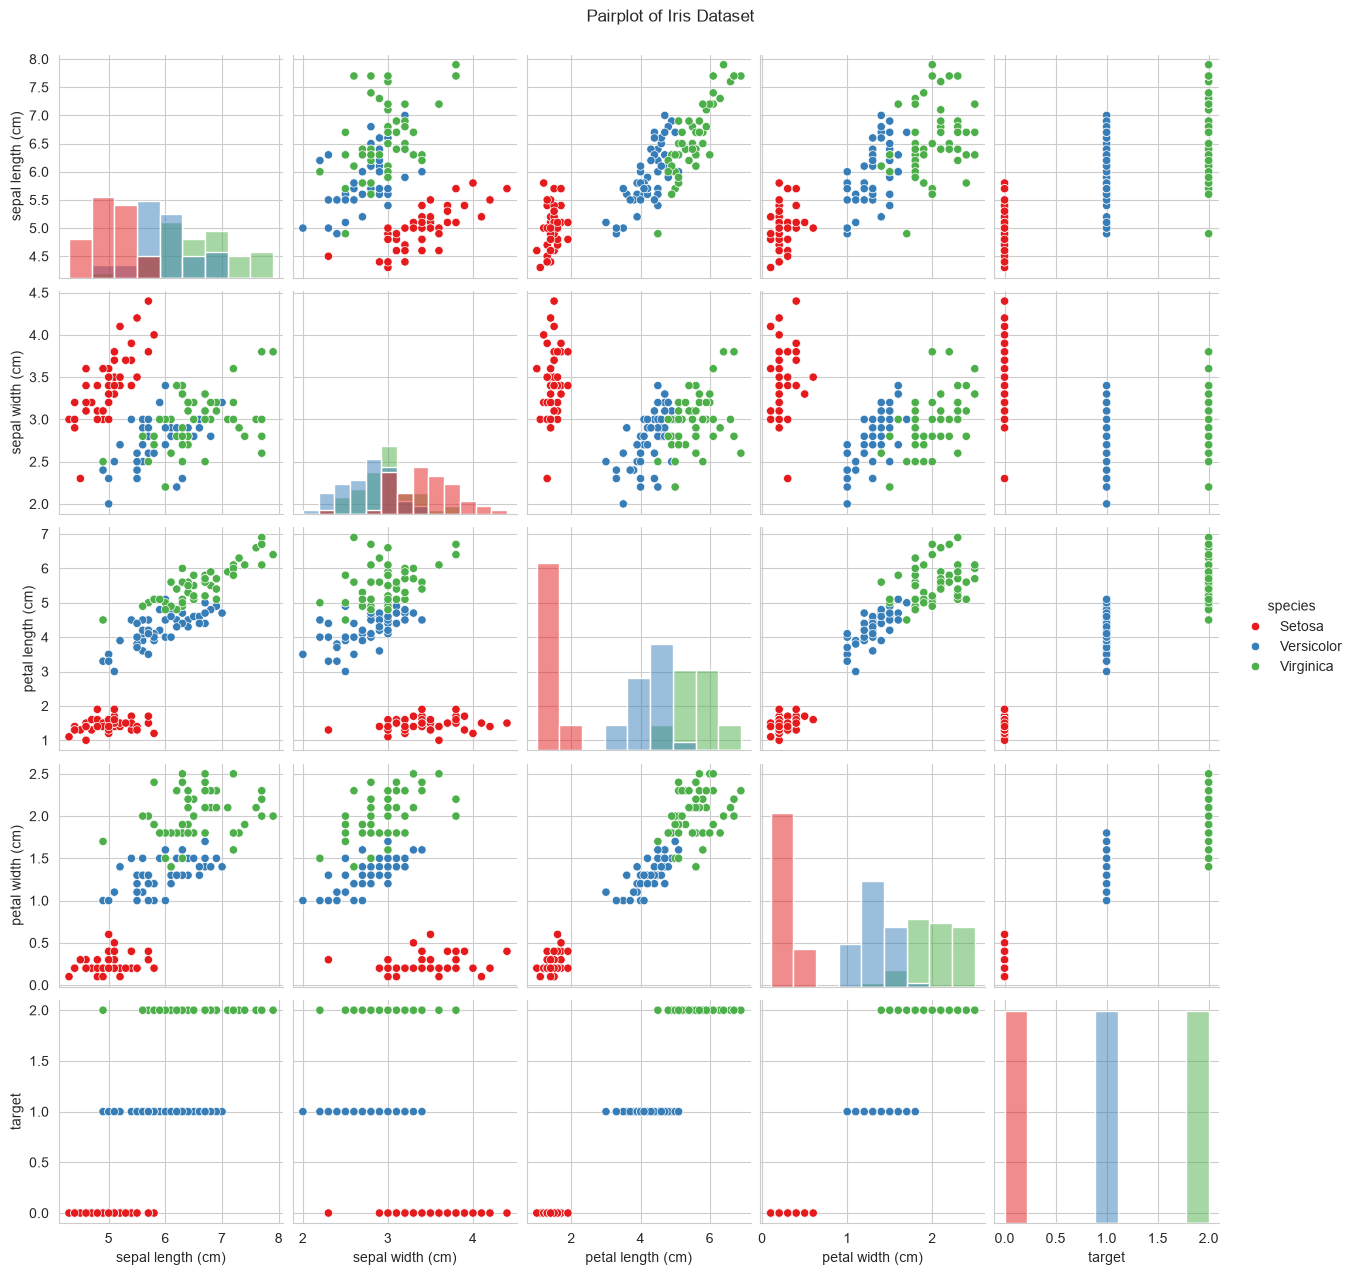

In [7]:
# Pairplot showing relationships between features
sns.pairplot(
    df,
    hue="species",
    palette="Set1",
    diag_kind="hist"
)

plt.suptitle(
    "Pairplot of Iris Dataset",
    y=1.02
)

plt.show()


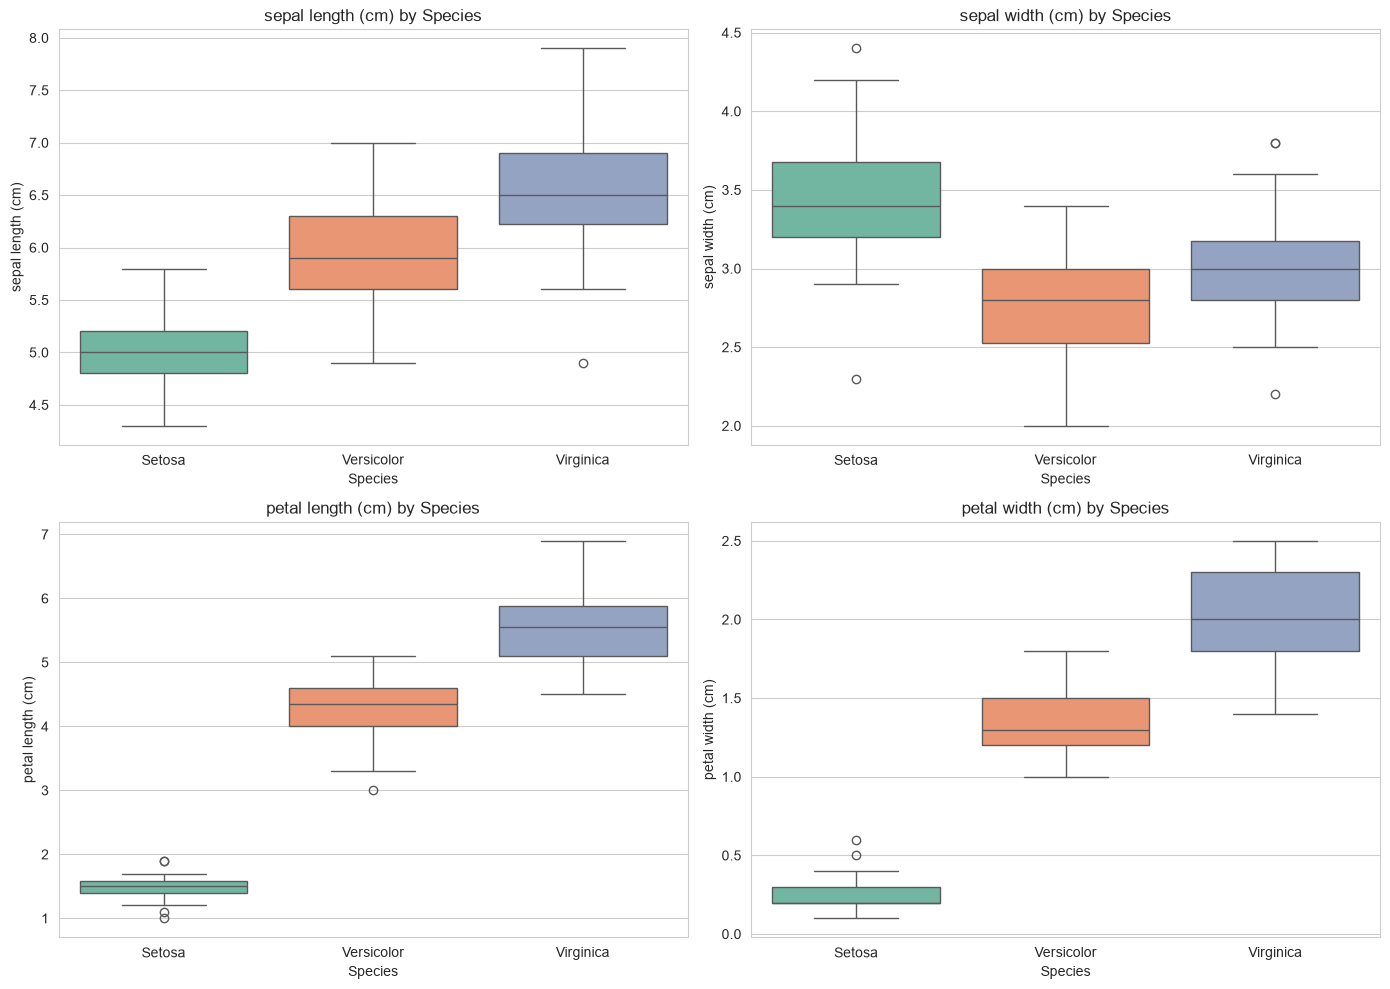

In [8]:
# Create box plots for all numerical features
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        hue="species",
        palette="Set2",
        legend=False,
        ax=ax
    )
    
    ax.set_title(f"{feature} by Species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


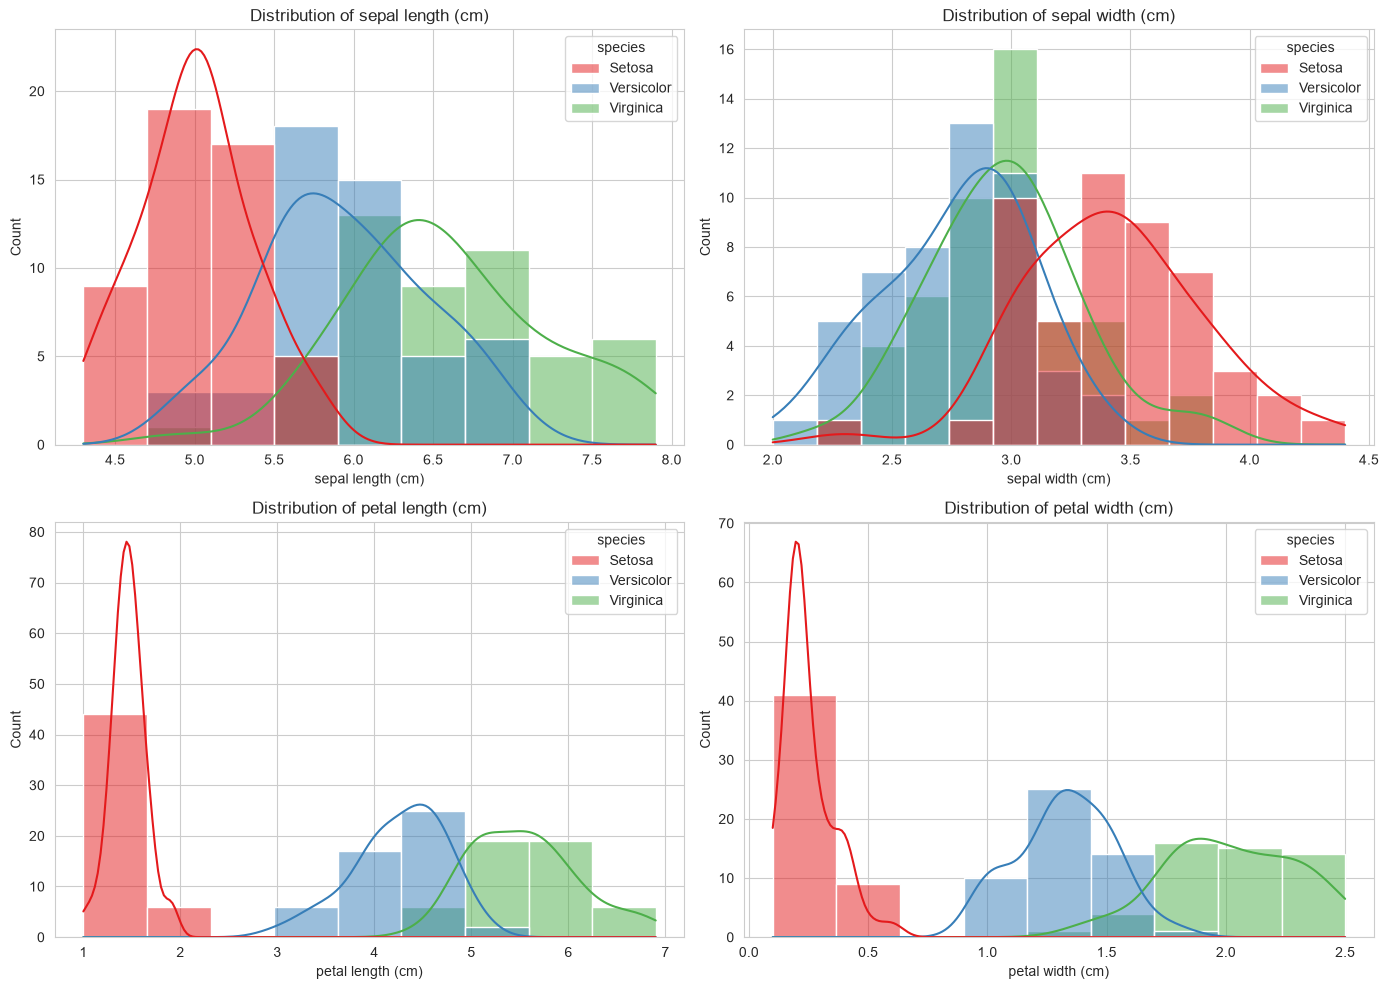

In [9]:
# Plot distributions of all numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        kde=True,
        palette="Set1",
        ax=ax
    )
    
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


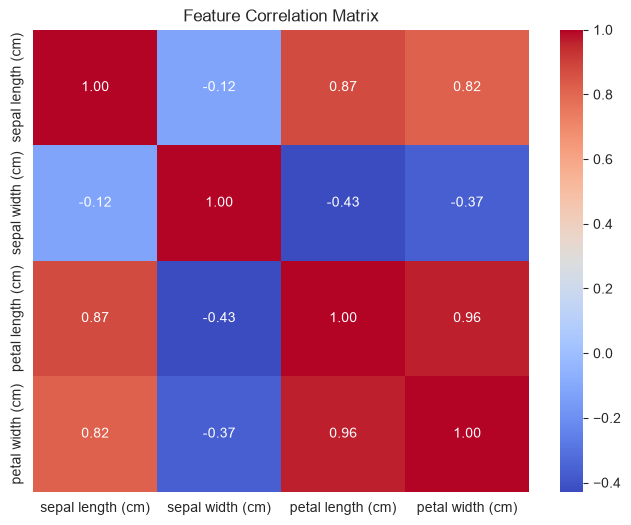

In [10]:
# Calculate correlation between numerical features
correlation_matrix = df[features].corr()

# Display correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()


In [11]:
# Calculate mean feature values for each species
species_means = df.groupby("species")[features].mean()

print("Mean measurements by species:")
display(species_means)
# Compare the range of each feature
feature_summary = pd.DataFrame({
    "Minimum": df[features].min(),
    "Maximum": df[features].max(),
    "Mean": df[features].mean(),
    "Standard Deviation": df[features].std()
})

display(feature_summary)


Mean measurements by species:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


,Minimum,Maximum,Mean,Standard Deviation
sepal length (cm),4.3,7.9,5.843333,0.828066
sepal width (cm),2.0,4.4,3.057333,0.435866
petal length (cm),1.0,6.9,3.758000,1.765298
petal width (cm),0.1,2.5,1.199333,0.762238


In [12]:
# X = input features
X = df[features]

# y = target variable
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (150, 4)
Target shape: (150,)


In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


In [14]:
# Create the scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions
logistic_predictions = logistic_model.predict(X_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))


Feature scaling completed.
Logistic Regression Accuracy: 0.9333


In [15]:
# Create KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:",
      round(knn_accuracy, 4))


KNN Accuracy: 0.9333


In [16]:
# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(
    X_train,
    y_train
)

# Make predictions
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate accuracy
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Accuracy:",
      round(decision_tree_accuracy, 4))


Decision Tree Accuracy: 0.9333


In [17]:
# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(
    X_train,
    y_train
)

# Make predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Calculate accuracy
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:",
      round(random_forest_accuracy, 4))


Random Forest Accuracy: 0.9


In [18]:
# Store model accuracies
model_accuracies = {
    "Logistic Regression": logistic_accuracy,
    "K-Nearest Neighbours": knn_accuracy,
    "Decision Tree": decision_tree_accuracy,
    "Random Forest": random_forest_accuracy
}

# Convert to DataFrame
accuracy_df = pd.DataFrame(
    list(model_accuracies.items()),
    columns=["Model", "Accuracy"]
)

# Sort from highest to lowest
accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

display(accuracy_df)


,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


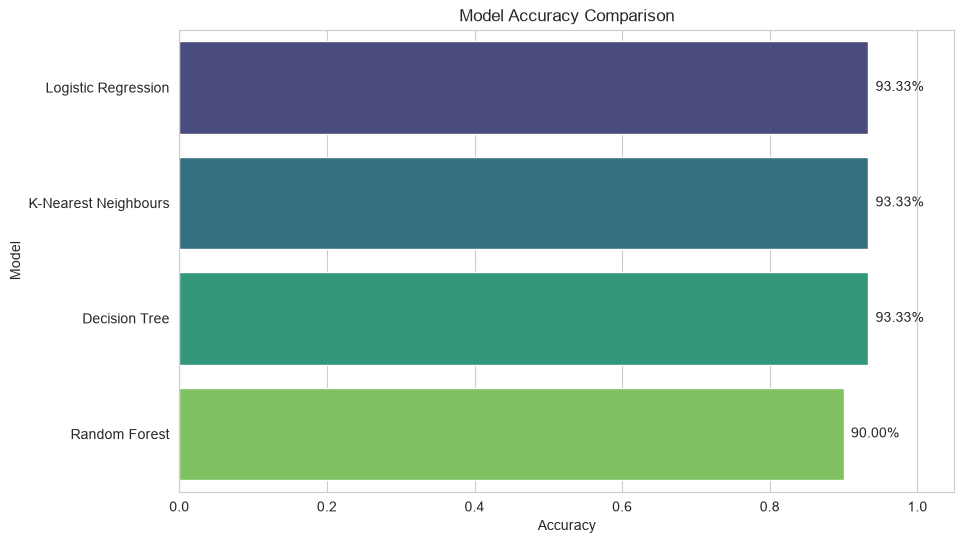

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=accuracy_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xlim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

# Add accuracy values to bars
for index, value in enumerate(accuracy_df["Accuracy"]):
    plt.text(
        value + 0.01,
        index,
        f"{value:.2%}",
        va="center"
    )

plt.show()


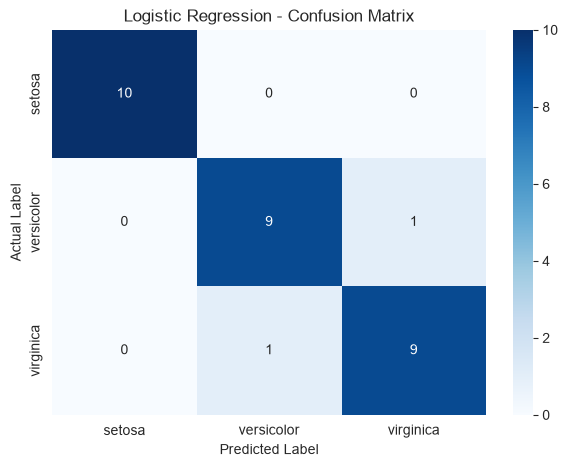

In [20]:
# Create confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [21]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)


Logistic Regression Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



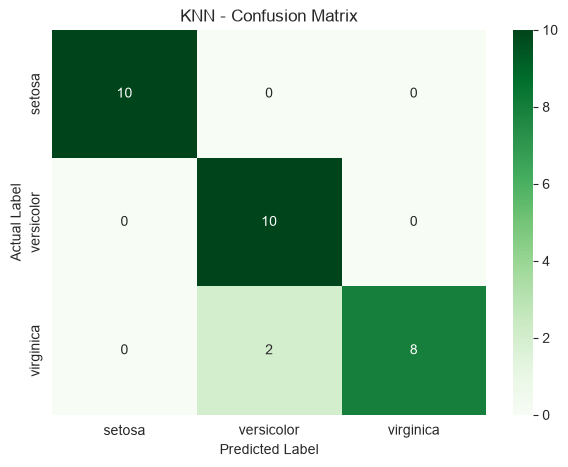

In [22]:
cm_knn = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [23]:
print("K-Nearest Neighbours Classification Report:\n")

print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=iris.target_names
    )
)


K-Nearest Neighbours Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



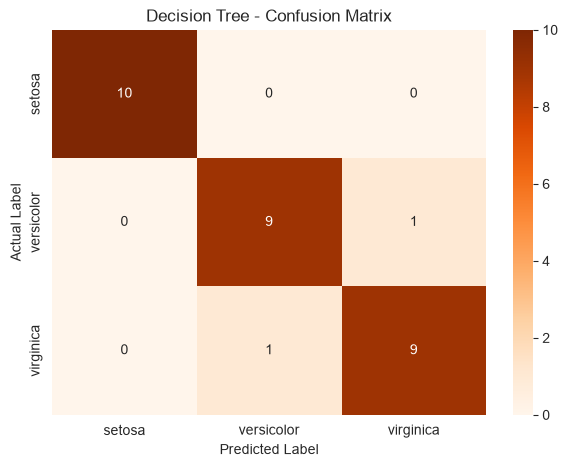

In [24]:
cm_tree = confusion_matrix(
    y_test,
    decision_tree_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


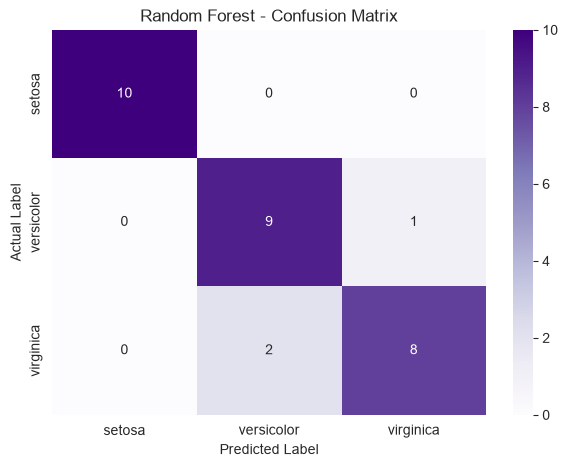

In [25]:
cm_random_forest = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_random_forest,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


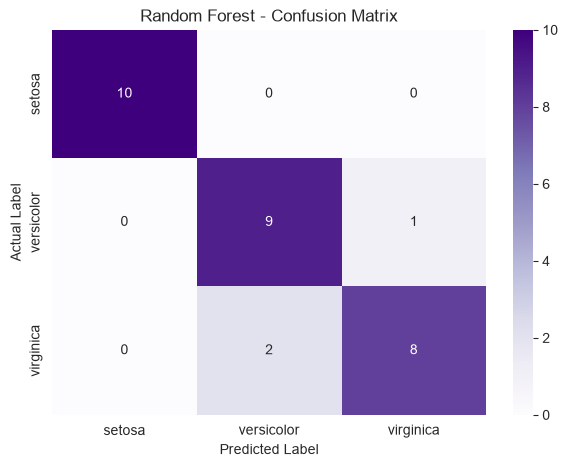

In [26]:
cm_random_forest = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_random_forest,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [27]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=iris.target_names
    )
)
from sklearn.metrics import precision_score, recall_score, f1_score

# Store predictions
predictions = {
    "Logistic Regression": logistic_predictions,
    "K-Nearest Neighbours": knn_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

# Create evaluation results
results = []

for model_name, prediction in predictions.items():
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            prediction,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

# Sort by F1 Score
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(results_df)


Random Forest Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,K-Nearest Neighbours,0.933333,0.944444,0.933333,0.932660
3,Random Forest,0.900000,0.902357,0.900000,0.899749


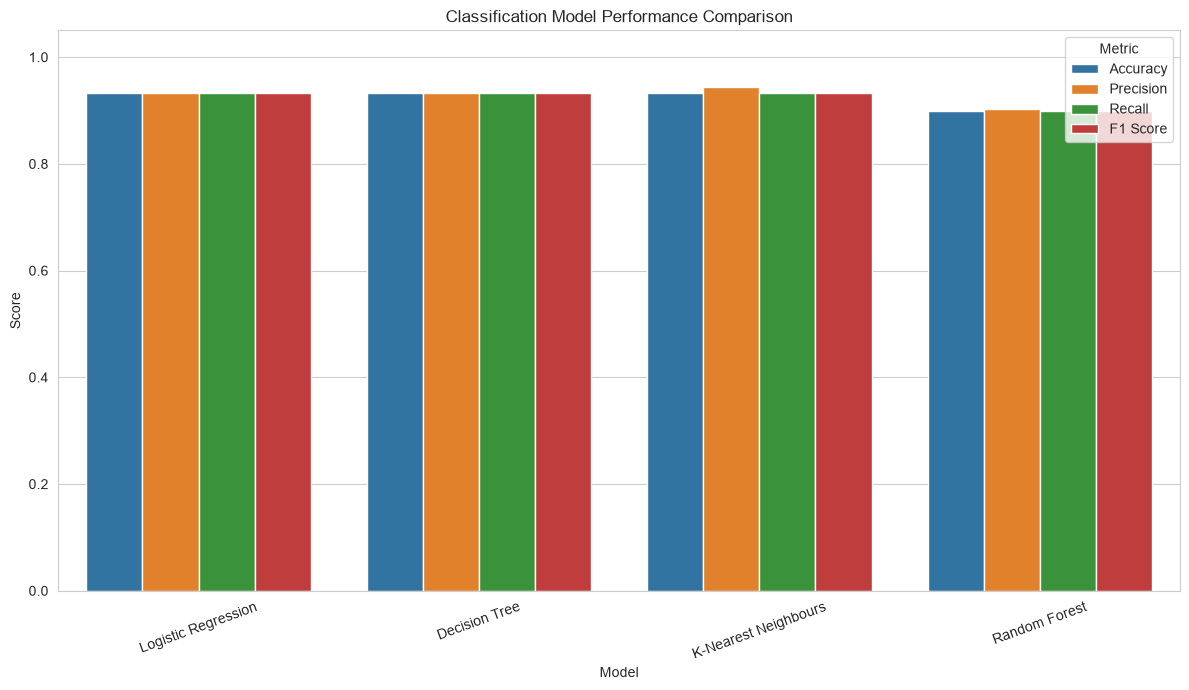

In [28]:
# Convert results into a format suitable for plotting
metrics_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=metrics_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)
plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.legend(title="Metric")
plt.tight_layout()

plt.show()


In [29]:
# Find the model with the highest F1 score
best_model_row = results_df.iloc[0]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_f1 = best_model_row["F1 Score"]

print("======================================")
print("BEST-PERFORMING MODEL")
print("======================================")

print(f"Model: {best_model_name}")
print(f"Accuracy:  {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1 Score:  {best_f1:.4f}")


BEST-PERFORMING MODEL
Model: Logistic Regression
Accuracy:  0.9333
Precision: 0.9333
Recall:    0.9333
F1 Score:  0.9333


In [30]:
print("\nConclusion:")
print(
    f"The best-performing model was {best_model_name}, "
    f"with an accuracy of {best_accuracy:.2%} "
    f"and an F1 score of {best_f1:.2%}."
)

print(
    "This model was selected because it achieved the highest "
    "overall F1 score among the evaluated classifiers."
)



Conclusion:
The best-performing model was Logistic Regression, with an accuracy of 93.33% and an F1 score of 93.33%.
This model was selected because it achieved the highest overall F1 score among the evaluated classifiers.


,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


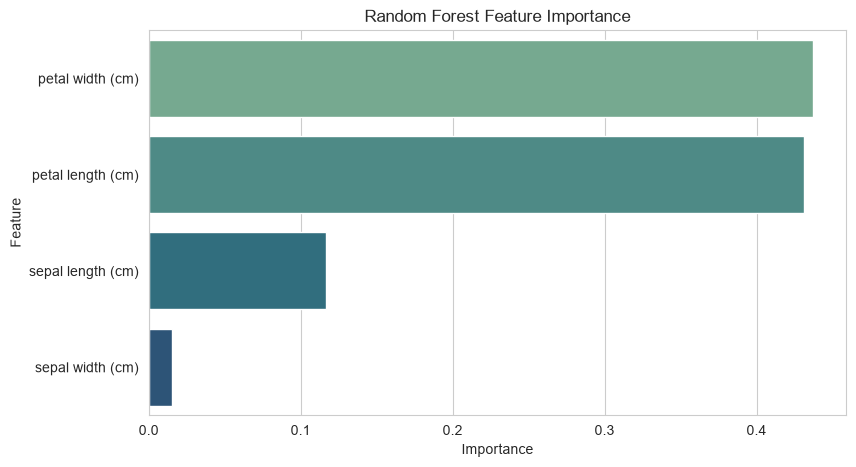

In [31]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)
# Plot feature importance
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="crest",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


In [32]:
# Example new flower measurements:
# [sepal length, sepal width, petal length, petal width]

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

# If Logistic Regression or KNN is the selected model,
# scale the new data first.
new_flower_scaled = scaler.transform(new_flower)

# Make prediction using Logistic Regression
prediction = logistic_model.predict(new_flower_scaled)

# Convert numerical prediction to species name
predicted_species = iris.target_names[prediction[0]]

print("Predicted species:", predicted_species)
# ============================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=200, random_state=42),
        X_train_scaled,
        X_test_scaled
    ),
    
    "K-Nearest Neighbours": (
        KNeighborsClassifier(n_neighbors=5),
        X_train_scaled,
        X_test_scaled
    ),
    
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        X_train,
        X_test
    ),
    
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        X_train,
        X_test
    )
}

evaluation_results = []

for name, (model, train_data, test_data) in models.items():
    
    # Train
    model.fit(train_data, y_train)
    
    # Predict
    predictions_model = model.predict(test_data)
    
    # Metrics
    accuracy = accuracy_score(y_test, predictions_model)
    precision = precision_score(
        y_test,
        predictions_model,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        predictions_model,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        predictions_model,
        average="weighted"
    )
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create final results DataFrame
final_results = pd.DataFrame(evaluation_results)

# Sort by F1 score
final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

display(final_results)


Predicted species: setosa


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,K-Nearest Neighbours,0.933333,0.944444,0.933333,0.932660
3,Random Forest,0.900000,0.902357,0.900000,0.899749
